# Medicine Stockout Prediction — Full Project Notebook (Weeks 1-3)

This single notebook contains the complete workflow in one continuous sequence:

- **Week 1** — Problem Definition & Exploratory Data Analysis
- **Week 2** — Data Cleaning, Preprocessing & Baseline Modeling
- **Week 3** — Advanced Modeling, Hyperparameter Tuning & Error Analysis

**Run all cells top to bottom, in order** — later sections (Week 2, Week 3) reuse
variables (`df`, `feature_cols`, `X_train`, etc.) created earlier in the notebook.
Some setup cells (e.g. importing libraries, loading the CSV) are repeated once at
the start of Week 2 for clarity — re-running them is harmless.


# Medicine Stockout Prediction - Week 1

This is my Week 1 work for the group project. I looked at the medicine stock data and did some basic exploring before we start building models next week.

Dataset used: medicine_stockout_prediction_AUGMENTED.csv (5653 rows, 19 columns)


## 1. What are we trying to do?

Health centers sometimes run out of medicine (this is called a "stockout"). We want to build a model that can predict if a medicine will run out **next month**, using the stock data from this month and past months.

**Inputs (things we know already):** how much stock was there at start of month, how much came in, how much was used, how much is left, and some numbers based on past months.

**Output (what we want to predict):** stockout_next_month - 1 if it will run out next month, 0 if not.

This is a classification problem (yes/no answer).


## 2. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


## 3. Load the data

In [2]:
df = pd.read_csv("medicine_stockout_prediction.csv")
print(df.shape)
df.head()


(5653, 19)


,hf_pk,productID,name1,date,openBalance,received,consumption,closeBalance,Stock_Cover,Days_of_Stock_Remaining,Previous_Month_Consumption,Consumption_Change,Rolling_3_Month_Consumption,Previous_Month_Received,Rolling_3_Month_Received,Previous_Month_OpenBalance,Previous_Month_CloseBalance,Previous_Month_Stockout,stockout_next_month
0,10166,20,"Water for Injection 10ml, Inj, Amp",2019-10-01,77,0,40,37,1.925000,57.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,10166,28,"Benzyl Benzoate 25%, Emulsion, 100ml, Bot",2019-10-01,0,0,200,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,10166,34,"Folic Acid 5mg, Tab",2019-10-01,1324,0,372,952,3.559140,106.774193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,10166,35,"Oxytocin 10IU, Inj, Amp",2019-10-01,116,0,17,99,6.823529,204.705882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,10166,38,"Albendazole 400mg, Tab",2019-10-01,0,0,16,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5653 entries, 0 to 5652
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hf_pk                        5653 non-null   int64  
 1   productID                    5653 non-null   int64  
 2   name1                        5653 non-null   str    
 3   date                         5653 non-null   str    
 4   openBalance                  5653 non-null   int64  
 5   received                     5653 non-null   int64  
 6   consumption                  5653 non-null   int64  
 7   closeBalance                 5653 non-null   int64  
 8   Stock_Cover                  5148 non-null   float64
 9   Days_of_Stock_Remaining      5148 non-null   float64
 10  Previous_Month_Consumption   5501 non-null   float64
 11  Consumption_Change           5501 non-null   float64
 12  Rolling_3_Month_Consumption  5501 non-null   float64
 13  Previous_Month_Received      

In [10]:
df.describe()


,hf_pk,productID,openBalance,received,consumption,closeBalance,Stock_Cover,Days_of_Stock_Remaining,Previous_Month_Consumption,Consumption_Change,Rolling_3_Month_Consumption,Previous_Month_Received,Rolling_3_Month_Received,Previous_Month_OpenBalance,Previous_Month_CloseBalance,Previous_Month_Stockout,stockout_next_month
count,5653.000000,5653.000000,5653.000000,5653.000000,5653.000000,5653.000000,5148.000000,5148.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5501.000000,5653.000000
mean,10017.048824,35.014329,435.193526,242.918273,255.197771,435.591191,5.329528,159.885852,255.895655,-1.495728,255.843180,246.475550,242.424286,434.352118,437.721687,0.165788,0.165045
std,41.472474,10.578288,974.563641,938.901326,510.458077,980.335289,51.782249,1553.467459,509.294781,342.792382,467.899244,947.967624,528.872831,963.655726,981.155313,0.371924,0.371254
min,10001.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3180.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10003.000000,22.000000,4.000000,0.000000,4.000000,4.000000,1.000000,30.000000,4.000000,-24.000000,4.666667,0.000000,0.000000,4.000000,4.000000,0.000000,0.000000
50%,10006.000000,35.000000,51.000000,0.000000,50.000000,50.000000,1.599435,47.983051,50.000000,0.000000,58.000000,0.000000,27.666667,51.000000,51.000000,0.000000,0.000000
75%,10009.000000,43.000000,311.000000,7.000000,204.000000,311.000000,3.000000,90.000000,205.000000,19.000000,230.000000,7.000000,180.000000,314.000000,312.000000,0.000000,0.000000
max,10166.000000,52.000000,11942.000000,12438.000000,4450.000000,11942.000000,2117.000000,63510.000000,4450.000000,4450.000000,3449.000000,12438.000000,4968.333333,11106.000000,11942.000000,1.000000,1.000000


## 4. Data dictionary (what each column means)



In [11]:
print("Number of facilities:", df['hf_pk'].nunique())
print(df['hf_pk'].value_counts())
print()
print("Number of medicines:", df['name1'].nunique())
print(df['name1'].unique())


Number of facilities: 11
hf_pk
10005    600
10002    576
10008    572
10007    564
10003    555
10009    516
10010    511
10006    490
10001    448
10004    416
10166    405
Name: count, dtype: int64

Number of medicines: 16
<StringArray>
[                       'Water for Injection 10ml, Inj, Amp',
                 'Benzyl Benzoate 25%, Emulsion, 100ml, Bot',
                                       'Folic Acid 5mg, Tab',
                                   'Oxytocin 10IU, Inj, Amp',
                                    'Albendazole 400mg, Tab',
                      'Oral Rehydration Salts (ORS), Sachet',
                      'Zinc Sulphate 20mg, Dispersible, Tab',
                    'Paracetamol (Acetaminophen) 500mg, Tab',
                        'Povidone Iodine 10%, Solution, Bot',
                                     'Methyldopa 250mg, Tab',
                'Ampicillin 500mg, Pdr for IM/IV, Inj, Vial',
       'Paracetamol (Acetaminophen) 250mg, Dispersible, Tab',
                 

## 5. Checking the target column

Before building a model we should see how many rows say "stockout" vs "no stockout".

stockout_next_month
0    4720
1     933
Name: count, dtype: int64
<bound method IndexOpsMixin.value_counts of 0       0
1       1
2       0
3       0
4       0
       ..
5648    0
5649    0
5650    0
5651    0
5652    0
Name: stockout_next_month, Length: 5653, dtype: int64>


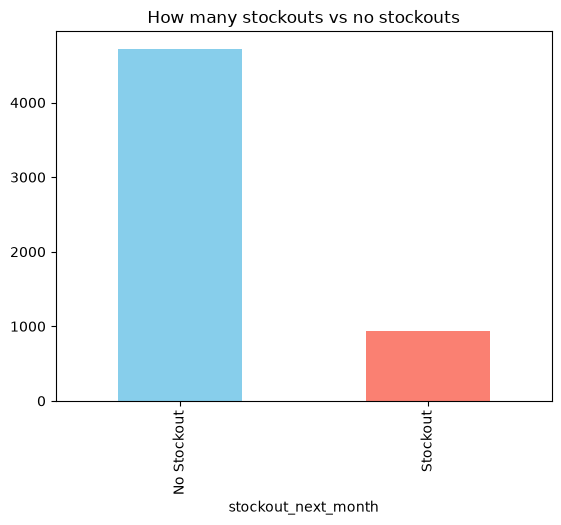

In [3]:
print(df['stockout_next_month'].value_counts())
print(df['stockout_next_month'].value_counts)

df['stockout_next_month'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.xticks([0,1], ['No Stockout','Stockout'])
plt.title("How many stockouts vs no stockouts")
plt.show()


So about 17% of the rows are stockouts and 83% are not. This means the data is a bit imbalanced - there are way more "no stockout" cases than "stockout" cases. 

## 6. Missing values

In [4]:
missing = df.isna().sum()
missing[missing > 0]


Stock_Cover                    505
Days_of_Stock_Remaining        505
Previous_Month_Consumption     152
Consumption_Change             152
Rolling_3_Month_Consumption    152
Previous_Month_Received        152
Rolling_3_Month_Received       152
Previous_Month_OpenBalance     152
Previous_Month_CloseBalance    152
Previous_Month_Stockout        152
dtype: int64

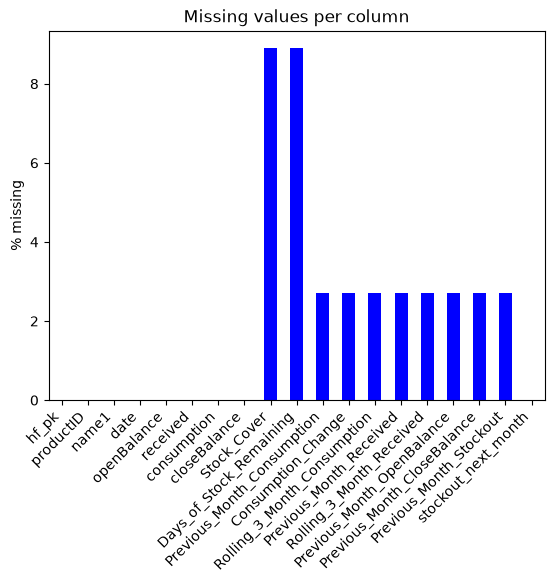

In [5]:
(df.isna().mean()*100).round(1).plot(kind='bar',  color='blue')
plt.ylabel("% missing")
plt.title("Missing values per column")
plt.xticks(rotation=45, ha='right')
plt.show()


Some columns have missing values. So we are going to drop them since their not many as we are going  to train our model



## 7. Looking at the numbers (distributions)

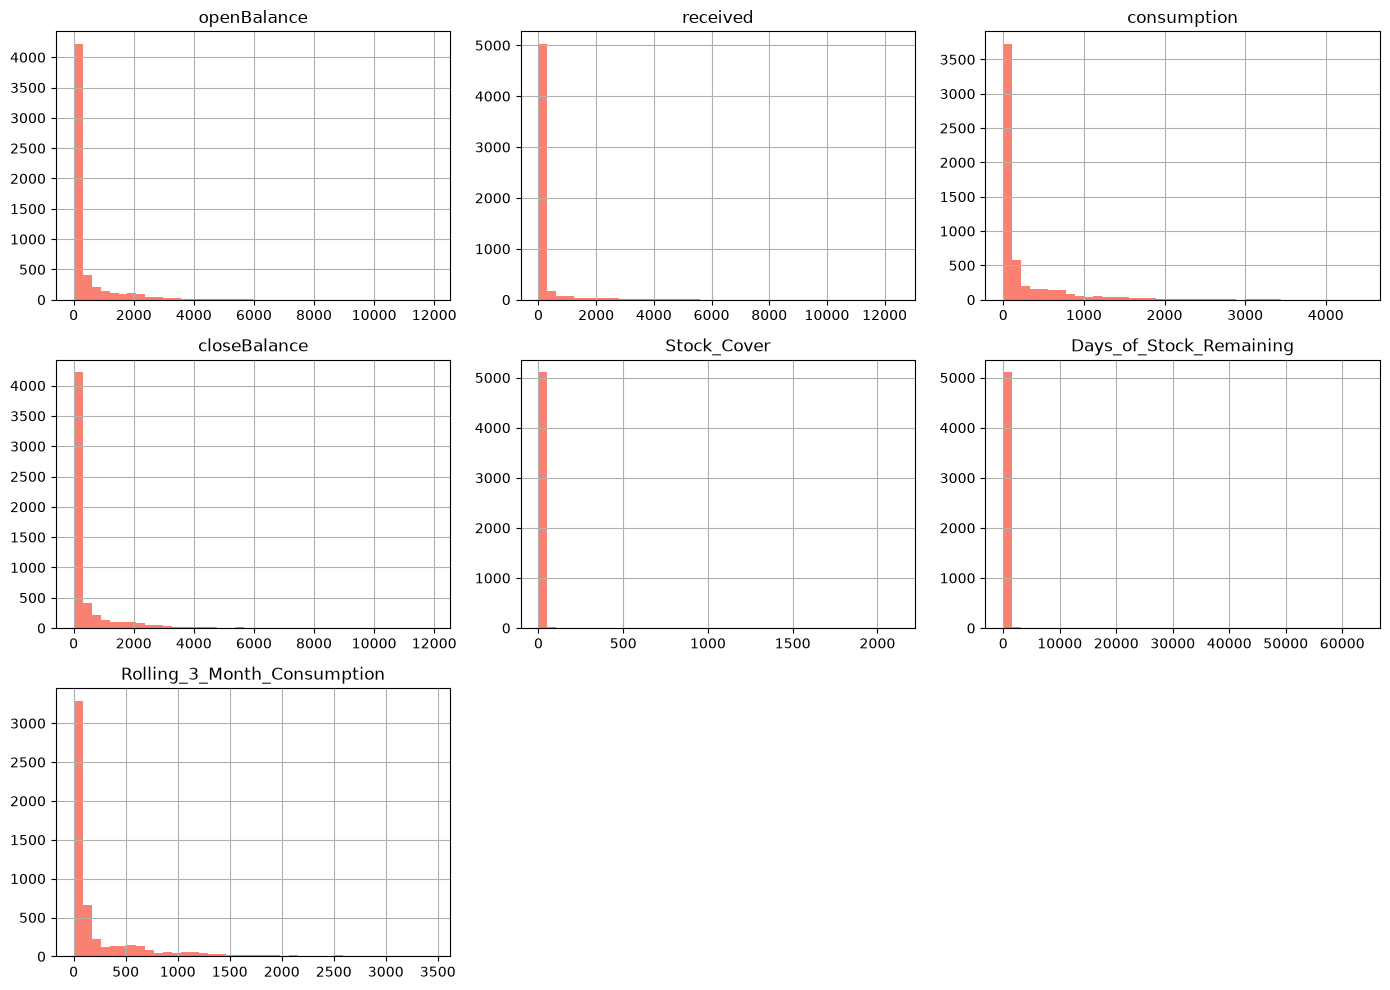

In [6]:
cols_to_check = ['openBalance', 'received', 'consumption', 'closeBalance',
                  'Stock_Cover', 'Days_of_Stock_Remaining', 'Rolling_3_Month_Consumption']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cols_to_check):
    df[col].dropna().hist(bins=40, ax=axes[i], color='salmon')
    axes[i].set_title(col)
for j in range(len(cols_to_check), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


Most of these numbers are lots of small values and a few really big ones. This makes sense because some medicines (like Paracetamol) get used a lot more than others (like Oxytocin). We might need to scale these numbers before putting them in a model.

In [ ]:
APPLYING LOG1 FOR NORMALIZING OUTLIERS

In [20]:
cols_to_check = df.select_dtypes(include=np.number).columns

df[cols_to_check] = np.log1p(df[cols_to_check])

## 8. Checking for outliers

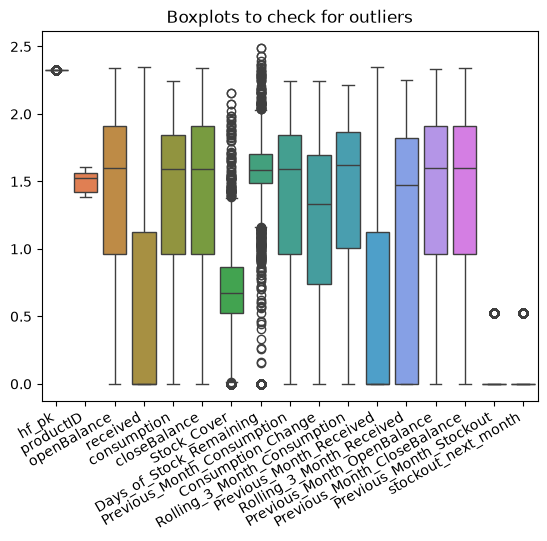

In [21]:
plt.figure()
sns.boxplot(data=df[cols_to_check])
plt.xticks(rotation=30, ha='right')
plt.title("Boxplots to check for outliers")
plt.show()


In [8]:
def outlier_percent(col):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    return round(((s < low) | (s > high)).mean()*100, 2)

for c in cols_to_check:
    print(c, ":", outlier_percent(c), "% outliers")


openBalance : 15.53 % outliers
received : 20.96 % outliers
consumption : 16.42 % outliers
closeBalance : 15.53 % outliers
Stock_Cover : 7.3 % outliers
Days_of_Stock_Remaining : 7.3 % outliers
Rolling_3_Month_Consumption : 15.27 % outliers


There are a few outliers but they mostly come from the medicines that are used in bigger amounts (like Zinc Sulphate). These are not mistakes in the data, just normal high numbers for those medicines. So we probably won't remove them.

## 9. Does stock cover relate to stockouts?

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15068\2194388151.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(['No Stockout','Stockout'])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15068\2194388151.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(['No stockout last month','Stockout last month'])


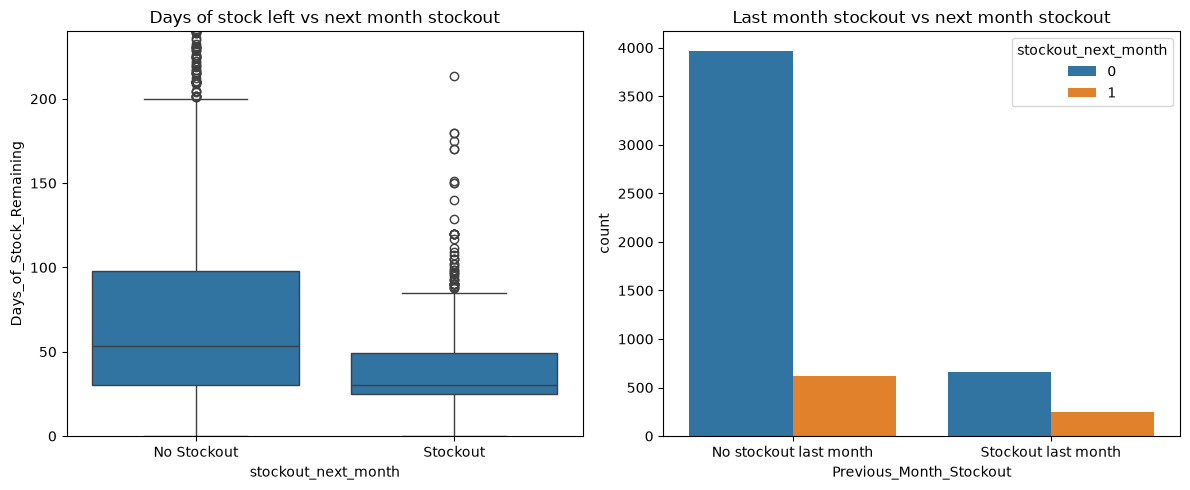

In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(data=df, x='stockout_next_month', y='Days_of_Stock_Remaining', ax=ax[0])
ax[0].set_ylim(0, df['Days_of_Stock_Remaining'].quantile(0.95))
ax[0].set_xticklabels(['No Stockout','Stockout'])
ax[0].set_title("Days of stock left vs next month stockout")

sns.countplot(data=df, x='Previous_Month_Stockout', hue='stockout_next_month', ax=ax[1])
ax[1].set_xticklabels(['No stockout last month','Stockout last month'])
ax[1].set_title("Last month stockout vs next month stockout")

plt.tight_layout()
plt.show()


Looks like when there are fewer days of stock left, a stockout next month is more likely. Also if a stockout happened last month, it's more likely to happen again. This makes sense and gives us a good sign these columns will actually help the model.

## 10. Correlation heatmap

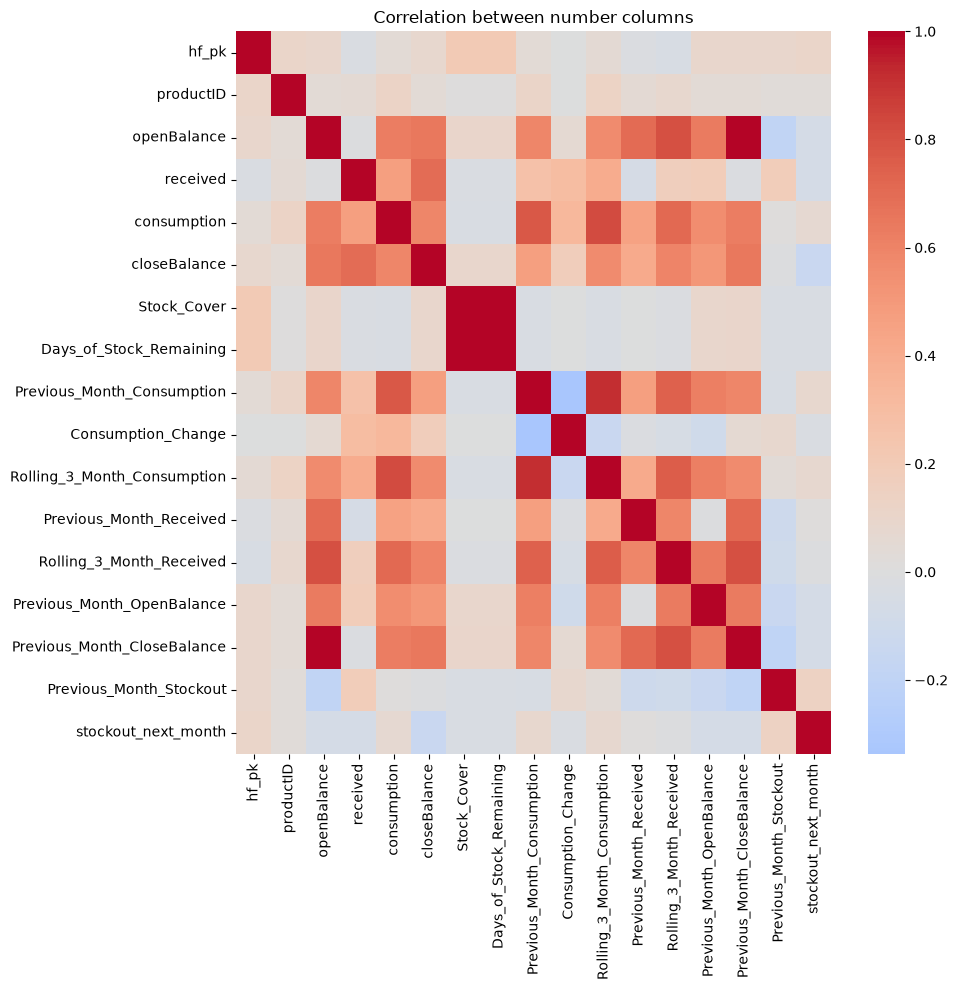

In [12]:
plt.figure(figsize=(10,10))
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation between number columns")
plt.tight_layout()
plt.show()


Stock_Cover and Days_of_Stock_Remaining are basically the same thing just multiplied by 30, so we probably only need one of them in the model, not both.

## 11. Quick look at facilities

In [13]:
facility_rate = df.groupby('hf_pk')['stockout_next_month'].mean().sort_values(ascending=True)
facility_rate


hf_pk
10009    0.083333
10003    0.099099
10008    0.108392
10007    0.113475
10004    0.127404
10001    0.162946
10010    0.174168
10002    0.175347
10005    0.243333
10006    0.246939
10166    0.311111
Name: stockout_next_month, dtype: float64

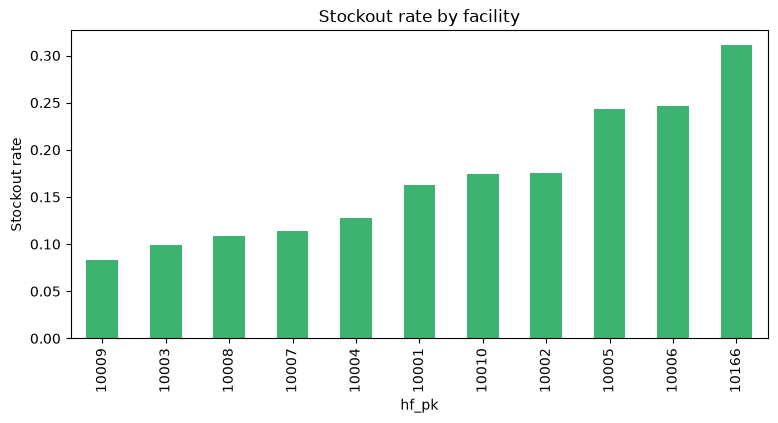

In [14]:
facility_rate.plot(kind='bar', color='mediumseagreen', figsize=(9,4))
plt.ylabel("Stockout rate")
plt.title("Stockout rate by facility")
plt.show()


Some facilities have way more stockouts than others. That's expected since 10 of these facilities are made-up data we generated to have more rows to train on, and only one facility (10166) is the real one.

In [3]:
df_clean = df.dropna().reset_index(drop=True)
print("Rows before:", len(df), "| Rows after dropping NaNs:", len(df_clean))
df_clean.head()


NameError: name 'df' is not defined

In [1]:
Feature Selection

- `openBalance`, `received`, `consumption`, `closeBalance`
- `Stock_Cover`
- `Previous_Month_Consumption`, `Consumption_Change`, `Rolling_3_Month_Consumption`
- `Previous_Month_Received`, `Rolling_3_Month_Received`
- `Previous_Month_OpenBalance`, `Previous_Month_CloseBalance`
- `Previous_Month_Stockout`

`Days_of_Stock_Remaining` is used as the target for the regression model, and `stockout_next_month` as the target for the classification models.

SyntaxError: invalid syntax (4289802158.py, line 1)

In [2]:
feature_cols = [
    'openBalance', 'received', 'consumption', 'closeBalance',
    'Stock_Cover', 'Previous_Month_Consumption', 'Consumption_Change',
    'Rolling_3_Month_Consumption', 'Previous_Month_Received',
    'Rolling_3_Month_Received', 'Previous_Month_OpenBalance',
    'Previous_Month_CloseBalance', 'Previous_Month_Stockout'
]

X = df_clean[feature_cols]
print("Feature matrix shape:", X.shape)
X.head(20)


NameError: name 'df_clean' is not defined

---
# Week 2: Data Cleaning, Preprocessing & Modeling

Building directly on the Week 1 EDA above, this section cleans the data, splits
it by time (not randomly), handles outliers and class imbalance, and trains the
first models (Logistic Regression baseline and XGBoost).


## 1. Import libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)


In [85]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable


## 2. Load the data

In [86]:
df = pd.read_csv("medicine_stockout_prediction.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
df.head()


(5653, 19)


,hf_pk,productID,name1,date,openBalance,received,consumption,closeBalance,Stock_Cover,Days_of_Stock_Remaining,Previous_Month_Consumption,Consumption_Change,Rolling_3_Month_Consumption,Previous_Month_Received,Rolling_3_Month_Received,Previous_Month_OpenBalance,Previous_Month_CloseBalance,Previous_Month_Stockout,stockout_next_month
0,10166,20,"Water for Injection 10ml, Inj, Amp",2019-10-01,77,0,40,37,1.925000,57.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,10166,28,"Benzyl Benzoate 25%, Emulsion, 100ml, Bot",2019-10-01,0,0,200,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,10166,34,"Folic Acid 5mg, Tab",2019-10-01,1324,0,372,952,3.559140,106.774193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,10166,35,"Oxytocin 10IU, Inj, Amp",2019-10-01,116,0,17,99,6.823529,204.705882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,10166,38,"Albendazole 400mg, Tab",2019-10-01,0,0,16,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


3.checking the missing values

In [87]:
df.isnull().sum

<bound method DataFrame.sum of       hf_pk  productID  name1   date  openBalance  received  consumption  \
0     False      False  False  False        False     False        False   
1     False      False  False  False        False     False        False   
2     False      False  False  False        False     False        False   
3     False      False  False  False        False     False        False   
4     False      False  False  False        False     False        False   
...     ...        ...    ...    ...          ...       ...          ...   
5648  False      False  False  False        False     False        False   
5649  False      False  False  False        False     False        False   
5650  False      False  False  False        False     False        False   
5651  False      False  False  False        False     False        False   
5652  False      False  False  False        False     False        False   

      closeBalance  Stock_Cover  Days_of_Stock_Remaining

4. class imbalance

In [88]:
df['stockout_next_month'].value_counts()      

stockout_next_month
0    4720
1     933
Name: count, dtype: int64

5.drop missing values

In [89]:
df.isnull().sum()

hf_pk                            0
productID                        0
name1                            0
date                             0
openBalance                      0
received                         0
consumption                      0
closeBalance                     0
Stock_Cover                    505
Days_of_Stock_Remaining        505
Previous_Month_Consumption     152
Consumption_Change             152
Rolling_3_Month_Consumption    152
Previous_Month_Received        152
Rolling_3_Month_Received       152
Previous_Month_OpenBalance     152
Previous_Month_CloseBalance    152
Previous_Month_Stockout        152
stockout_next_month              0
dtype: int64

> **Kumbuka (cleanup):** Sehemu ya awali ya majaribio ya kusafisha data (log1p transform, one-hot get_dummies, na ColumnTransformer ya random split) imeondolewa hapa kwa sababu haikuwa ikitumika tena kwenye model ya mwisho — `df_clean`, `X_train` na `X_test` halisi vinavyotumika vinatengenezwa upya chini (sehemu ya '3. Clean missing values' na kuendelea), kwa kutumia time-based split. Hii inaondoa mkanganyiko na kufanya notebook iwe reproducible zaidi.

## 3. Clean missing values

From Week 1 we know missing values come from two places:
- First month of a medicine at a facility has no "previous month" data (`Previous_Month_*` columns).
- `Stock_Cover` / `Days_of_Stock_Remaining` are empty when consumption was 0 that month.

We also learned `Stock_Cover` and `Days_of_Stock_Remaining` are basically the same thing
(one is the other x 30), so we only keep `Days_of_Stock_Remaining` to avoid duplicate info.


In [32]:
# Drop the first-month rows (no lag features available for them)
df_clean = df.dropna(subset=["Previous_Month_Consumption"]).copy()
print("Rows after dropping first-month rows:", df_clean.shape)

# For rows where Days_of_Stock_Remaining is missing (consumption was 0 that month),
# fill with a large number - 0 consumption means stock will last a long time, not a short time
df_clean["Days_of_Stock_Remaining"] = df_clean["Days_of_Stock_Remaining"].fillna(
    df_clean["Days_of_Stock_Remaining"].max()
)

df_clean.isna().sum()[df_clean.isna().sum() > 0]


Rows after dropping first-month rows: (5501, 19)


Stock_Cover    497
dtype: int64

## 4. Select features

We drop:
- `hf_pk`, `productID`, `name1` - identifiers, not useful as raw numbers for this first model
- `date` - only needed for the time-based split, not as a model input
- `openBalance`/`closeBalance` this-month values that would leak information -
  actually `openBalance` is known at the start of the month so it's fine, but
  `closeBalance` for the *current* month is really close to knowing next month's opening
  stock, so we keep it here since it's still "this month" info, not next month's.
- `Stock_Cover` - duplicate of `Days_of_Stock_Remaining`


In [33]:
feature_cols = [
    "openBalance", "received", "consumption", "closeBalance",
    "Days_of_Stock_Remaining",
    "Previous_Month_Consumption", "Consumption_Change", "Rolling_3_Month_Consumption",
    "Previous_Month_Received", "Rolling_3_Month_Received",
    "Previous_Month_OpenBalance", "Previous_Month_CloseBalance",
    "Previous_Month_Stockout",
]
target_col = "stockout_next_month"

X = df_clean[feature_cols]
y = df_clean[target_col]
print("Features:", X.shape, " Target:", y.shape)


Features: (5501, 13)  Target: (5501,)


## 5. Train / Validation / Test split by date (not random!)

We must NOT randomly shuffle rows into train/test, because that would let the model
"see the future" (e.g. train on a 2023 row and test on a 2020 row from the same product).
Instead we pick two cutoff dates and split chronologically into three sets:

- **Train**: everything before the first cutoff - used to fit the model.
- **Validation**: between the two cutoffs - held out from training, used for hyperparameter
  tuning and model comparison in Week 3 (not touched when reporting final metrics here).
- **Test**: everything from the second cutoff onward - untouched until final evaluation.


In [ ]:
train_cutoff = "2022-01-01"
test_cutoff = "2022-06-01"

train_mask = df_clean["date"] < train_cutoff
val_mask = (df_clean["date"] >= train_cutoff) & (df_clean["date"] < test_cutoff)
test_mask = df_clean["date"] >= test_cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:     ", X_train.shape, " stockout rate:", round(y_train.mean(), 3))
print("Validation:", X_val.shape, " stockout rate:", round(y_val.mean(), 3))
print("Test:      ", X_test.shape, " stockout rate:", round(y_test.mean(), 3))


## 5b. Check for outliers / skewness

Before training, let's look at the spread of the numeric features on the **training set only**
(never look at test/validation distributions when making preprocessing decisions - that would be a
form of leakage). Consumption and balance-type columns are typically right-skewed (a few
facilities/products with very large volumes), which can hurt models that are sensitive to scale
and distance, like Logistic Regression.


In [ ]:
plt.figure(figsize=(15, 6))
X_train.boxplot()
plt.xticks(rotation=90)
plt.ylabel("value")
plt.title("Feature spread on the training set (before log transform)")
plt.show()


### Handling skewness with log1p

We apply `np.log1p` (log(1 + x)) to the non-negative, volume-type columns to pull in extreme values
and make their distributions less skewed. We deliberately exclude:

- `Consumption_Change` - this can be **negative** (consumption went down month-to-month), and
  `log1p` is undefined for values < -1, so we leave it as-is.
- `Previous_Month_Stockout` - this is a binary 0/1 flag, not a continuous quantity, so a log
  transform doesn't apply.

`log1p` is a fixed, deterministic function (it doesn't estimate anything from the data - unlike
`StandardScaler`, which learns a mean/std), so applying it separately to `X_train`, `X_val` and
`X_test` is safe and introduces **no data leakage** between the sets.


In [ ]:
skewed_cols = [
    "openBalance", "received", "consumption", "closeBalance",
    "Days_of_Stock_Remaining",
    "Previous_Month_Consumption", "Rolling_3_Month_Consumption",
    "Previous_Month_Received", "Rolling_3_Month_Received",
    "Previous_Month_OpenBalance", "Previous_Month_CloseBalance",
]

for data_split in (X_train, X_val, X_test):
    data_split[skewed_cols] = np.log1p(data_split[skewed_cols])

plt.figure(figsize=(15, 6))
X_train.boxplot()
plt.xticks(rotation=90)
plt.ylabel("value")
plt.title("Feature spread on the training set (after log1p)")
plt.show()


## 6. Handle class imbalance

Only ~15-17% of rows are stockouts. Without adjusting for this, the model can get ~85%
accuracy just by always predicting "no stockout", which is useless. XGBoost has a
`scale_pos_weight` parameter for this - set it to (number of negative rows / number of
positive rows) in the training set so it pays more attention to the minority class.


In [35]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 2))


scale_pos_weight: 5.66


## 7. Train the XGBoost model

In [36]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
)

model.fit(X_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 8. Evaluate the model

We look at precision/recall/F1 (not just accuracy, since the data is imbalanced) and
ROC-AUC. For this problem, **recall on class 1 (stockout) matters a lot** - missing a
real stockout is worse than a false alarm, since a false alarm just means someone
double-checks stock that turned out to be fine.


              precision    recall  f1-score   support

 No Stockout       0.92      0.82      0.87      1647
    Stockout       0.43      0.65      0.52       343

    accuracy                           0.79      1990
   macro avg       0.67      0.73      0.69      1990
weighted avg       0.83      0.79      0.81      1990

ROC-AUC: 0.842


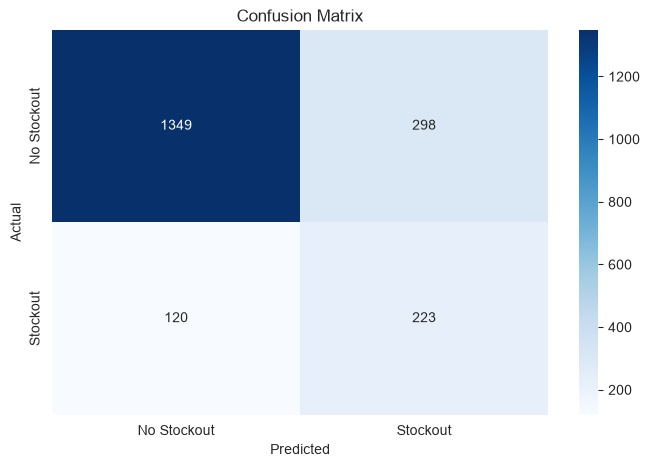

In [37]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Stockout", "Stockout"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Stockout", "Stockout"], yticklabels=["No Stockout", "Stockout"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()


## 9. Feature importance

Which features is the model relying on most?


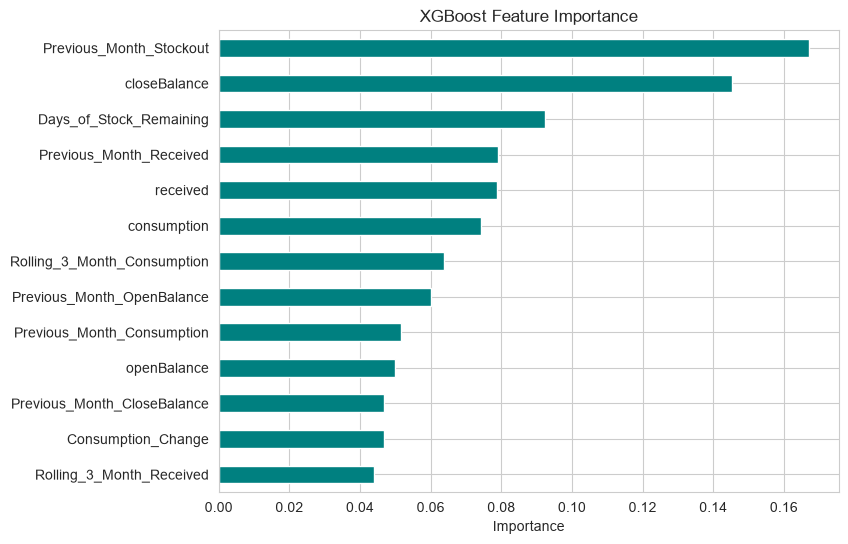

In [38]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", figsize=(8, 6), color="teal")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()


## 10. Threshold tuning (optional but useful)

By default, XGBoost predicts class 1 when probability > 0.5. Since we care more about
catching stockouts (recall) than avoiding false alarms, we can try a lower threshold
and see how precision/recall trade off.


In [45]:
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_t, target_names=["No Stockout", "Stockout"], output_dict=True)
    print(f"Threshold={threshold} -> Stockout precision={report['Stockout']['precision']:.2f}, "
          f"recall={report['Stockout']['recall']:.2f}, f1={report['Stockout']['f1-score']:.2f}")


Threshold=0.5 -> Stockout precision=0.43, recall=0.65, f1=0.52
Threshold=0.4 -> Stockout precision=0.38, recall=0.77, f1=0.51
Threshold=0.3 -> Stockout precision=0.35, recall=0.85, f1=0.50
Threshold=0.2 -> Stockout precision=0.32, recall=0.92, f1=0.47


## 12. Baseline comparison: Logistic Regression

XGBoost can find complex patterns, but we should check it's actually better than a
simple baseline. Logistic Regression is a good baseline because it's simple and
interpretable - if XGBoost barely beats it, that tells us the extra complexity might
not be worth it.

Unlike trees, Logistic Regression is sensitive to feature scale (a feature like
`closeBalance` in the thousands would dominate one like `Consumption_Change` in the tens
just because of its size), so we scale the features first with `StandardScaler`.


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    class_weight="balanced",  # same idea as scale_pos_weight - pay more attention to stockouts
    max_iter=1000,
    random_state=42,
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=["No Stockout", "Stockout"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))


              precision    recall  f1-score   support

 No Stockout       0.91      0.79      0.85      1647
    Stockout       0.38      0.62      0.47       343

    accuracy                           0.76      1990
   macro avg       0.65      0.70      0.66      1990
weighted avg       0.82      0.76      0.78      1990

ROC-AUC: 0.796


### Compare the two models side by side

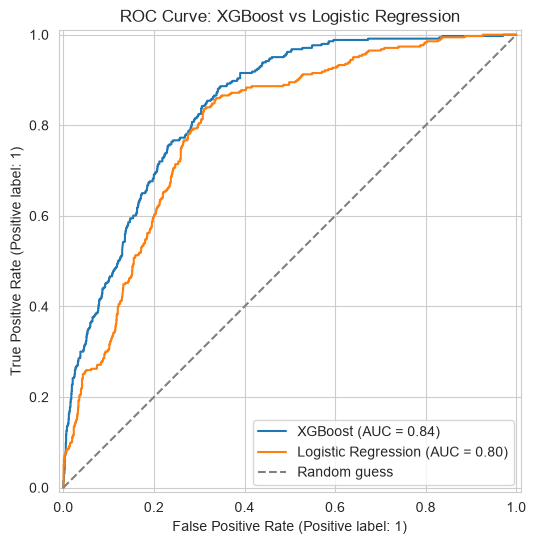

,Model,ROC-AUC
0,XGBoost,0.842
1,Logistic Regression,0.796


In [41]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name="XGBoost", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve: XGBoost vs Logistic Regression")
ax.legend()
plt.show()

comparison = pd.DataFrame({
    "Model": ["XGBoost", "Logistic Regression"],
    "ROC-AUC": [round(roc_auc_score(y_test, y_proba), 3), round(roc_auc_score(y_test, y_proba_lr), 3)],
})
comparison


### What the Logistic Regression coefficients tell us

One advantage of Logistic Regression: we can directly read which features push the
prediction toward "stockout" (positive coefficient) or "no stockout" (negative
coefficient) - useful for explaining the model to people who aren't data scientists.


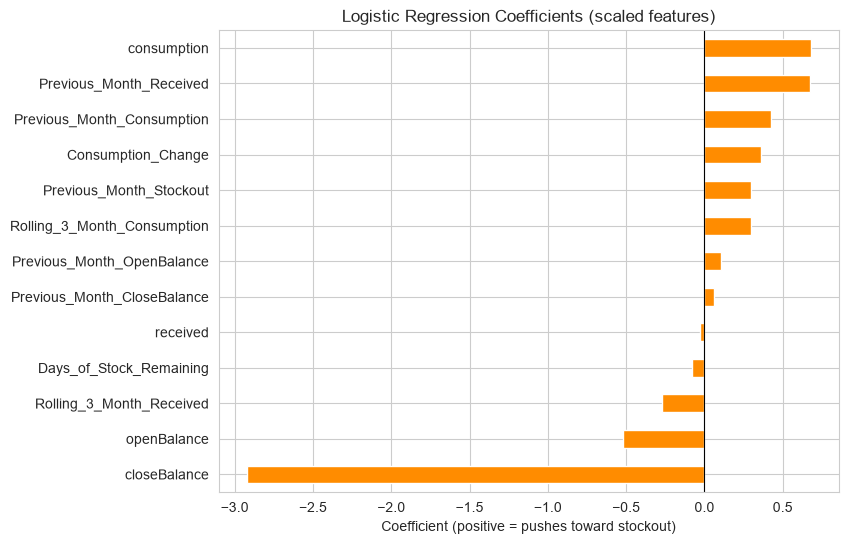

In [42]:
coefs = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values()
coefs.plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Logistic Regression Coefficients (scaled features)")
plt.xlabel("Coefficient (positive = pushes toward stockout)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()


## 13. SMOTE - another way to handle imbalance

`scale_pos_weight` and `class_weight="balanced"` tell the model to *pay more attention*
to the minority class, but the training data itself stays imbalanced.

**SMOTE (Synthetic Minority Oversampling Technique)** instead changes the training data:
it creates new, synthetic "stockout" rows by interpolating between real stockout rows
that are close to each other in feature space - so the class 1 rows literally increase
in number until the training set is balanced (roughly 50/50).

Important: SMOTE is only applied to the **training set**, never the test set - the test
set must stay a realistic, real-world (imbalanced) sample so the evaluation is honest.

Needs: `pip install imbalanced-learn`


In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())


ModuleNotFoundError: No module named 'imblearn'

### Train XGBoost on the SMOTE-balanced data

Since the training data is now balanced, we don't need `scale_pos_weight` anymore -
we train a plain XGBoost and compare it to the two approaches above.


In [ ]:
model_smote = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)
y_proba_smote = model_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_smote, target_names=["No Stockout", "Stockout"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_smote), 3))


### Compare all three approaches side by side

## 11. What I found / next steps

- Time-based split avoids "seeing the future", which a random split would not have caught.
- `scale_pos_weight` and threshold tuning both help with the class imbalance - which one
  we rely on more depends on whether the team wants to fix the decision threshold or let
  the model itself weight the classes.
- Feature importance should be compared against Week 1's correlation findings (e.g. does
  `Days_of_Stock_Remaining` / `Previous_Month_Stockout` come out on top, matching what we
  saw in the EDA boxplots?).
- Logistic Regression baseline is now added (section 12) - compare its ROC-AUC and
  recall against XGBoost to see how much the extra model complexity actually buys us.
- SMOTE comparison is now added (section 13) - compare its ROC-AUC/recall against
  scale_pos_weight and class_weight to decide which imbalance approach the team prefers.
- Next: try LightGBM as another comparison point, and consider adding
  `hf_pk`/`productID` as categorical features (one-hot or target encoding) to see if
  facility/product identity adds predictive power beyond the numeric features.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name="XGBoost (scale_pos_weight)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression (class_weight)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_smote, name="XGBoost (SMOTE)", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("Comparing imbalance-handling approaches")
ax.legend()
plt.show()

comparison_all = pd.DataFrame({
    "Approach": ["XGBoost + scale_pos_weight", "Logistic Regression + class_weight", "XGBoost + SMOTE"],
    "ROC-AUC": [
        round(roc_auc_score(y_test, y_proba), 3),
        round(roc_auc_score(y_test, y_proba_lr), 3),
        round(roc_auc_score(y_test, y_proba_smote), 3),
    ],
})
comparison_all


---
# Week 3 - Advanced Modeling, Tuning & Evaluation

Building on Week 2 (cleaned data, time-based Train/Validation/Test split, baseline models),
this section adds a **third distinct model type** and does **systematic hyperparameter tuning**
using the Validation set - the Test set stays untouched until the very final comparison.


## 14. Random Forest - a third model type

We already have XGBoost (boosted trees) and Logistic Regression (linear). Random Forest is a
**bagging**-based tree model - unlike XGBoost, trees are built independently on random subsets
of rows/features and then averaged, instead of correcting each other's mistakes in sequence.
It gives us a genuinely different model family to compare against, as the checklist asks for
2-3 distinct model types.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["No Stockout", "Stockout"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))


## 15. Hyperparameter tuning with GridSearchCV (using the Validation set)

`GridSearchCV` normally does its own k-fold cross-validation internally, which would mix our
carefully time-ordered Train and Validation rows back together at random - exactly the kind of
leakage we avoided in Week 2. To keep the time-based split intact, we use `PredefinedSplit`:
it tells `GridSearchCV` "always train on the Train rows, always score on the Validation rows" -
no shuffling, no leakage. The Test set is not part of this step at all.


In [ ]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit

# Stack Train + Validation, and mark which rows belong to which:
# -1 means "always used for training", 0 means "use this row as the held-out validation fold"
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
test_fold = np.concatenate([
    np.full(len(X_train), -1),
    np.full(len(X_val), 0),
])
ps = PredefinedSplit(test_fold)

param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
}

grid_model = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=grid_model,
    param_grid=param_grid,
    cv=ps,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_search.fit(X_trainval, y_trainval)

print("Best params:", grid_search.best_params_)
print("Best validation ROC-AUC:", round(grid_search.best_score_, 3))


### Final evaluation of the tuned model on the Test set

Now - and only now - do we touch the Test set, using the best hyperparameters found above.


In [ ]:
best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=["No Stockout", "Stockout"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_tuned), 3))


## 16. Compare every model side by side (Week 2 + Week 3)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name="XGBoost (scale_pos_weight)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression (class_weight)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_smote, name="XGBoost (SMOTE)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest (class_weight)", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_tuned, name="XGBoost (tuned via GridSearchCV)", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("Week 2 + Week 3 model comparison")
ax.legend()
plt.show()

comparison_week3 = pd.DataFrame({
    "Approach": [
        "XGBoost + scale_pos_weight",
        "Logistic Regression + class_weight",
        "XGBoost + SMOTE",
        "Random Forest + class_weight",
        "XGBoost tuned (GridSearchCV)",
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_test, y_proba), 3),
        round(roc_auc_score(y_test, y_proba_lr), 3),
        round(roc_auc_score(y_test, y_proba_smote), 3),
        round(roc_auc_score(y_test, y_proba_rf), 3),
        round(roc_auc_score(y_test, y_proba_tuned), 3),
    ],
})
comparison_week3.sort_values("ROC-AUC", ascending=False)


## 17. Week 3 notes / next steps

- Three distinct model families are now compared: boosted trees (XGBoost), bagged trees
  (Random Forest), and a linear model (Logistic Regression) - satisfies the "2-3 distinct
  model types" checklist item.
- Hyperparameters were tuned with `GridSearchCV` restricted to the Validation fold only
  (via `PredefinedSplit`), so the Test set ROC-AUC above is an honest, untouched estimate.
- Next for error analysis: break down false negatives (missed stockouts) by product/facility
  to see if certain drugs or health facilities are systematically harder to predict.
- Next for Week 4: pick the best-performing, most explainable model for the final report and
  demo, and start drafting the README + individual contribution log for all 10 members.


## 18. Error analysis by product / facility

Overall ROC-AUC and recall tell us how the model does *on average*, but they can hide the fact
that some products or health facilities are much harder to predict than others. We bring back
the identifying columns (`hf_pk`, `productID`, `name1`) for the Test rows only - purely for
reporting, they are never fed into the model - and look at where the tuned XGBoost model
(from Section 15) makes the most mistakes.


In [ ]:
id_cols = ["hf_pk", "productID", "name1", "date"]

error_df = df_clean.loc[X_test.index, id_cols].copy()
error_df["actual"] = y_test.values
error_df["predicted"] = y_pred_tuned
error_df["predicted_proba"] = y_proba_tuned

error_df["outcome"] = np.select(
    [
        (error_df["actual"] == 1) & (error_df["predicted"] == 1),
        (error_df["actual"] == 1) & (error_df["predicted"] == 0),
        (error_df["actual"] == 0) & (error_df["predicted"] == 1),
    ],
    ["True Positive", "False Negative (missed)", "False Positive (false alarm)"],
    default="True Negative",
)

error_df["outcome"].value_counts()


### Which products get missed most often? (False Negatives)

A False Negative here means: the medicine actually ran out next month, but the model predicted
it wouldn't. These are the most costly mistakes for a health facility - worth ranking first.


In [ ]:
actual_stockouts = error_df[error_df["actual"] == 1]

product_recall = (
    actual_stockouts
    .groupby("name1")["predicted"]
    .agg(n_actual_stockouts="count", n_caught="sum")
)
product_recall["recall"] = (product_recall["n_caught"] / product_recall["n_actual_stockouts"]).round(2)

# Only look at products with enough real stockout cases in the test set to be meaningful
product_recall[product_recall["n_actual_stockouts"] >= 5].sort_values("recall").head(10)


### Which health facilities get missed most often?


In [ ]:
facility_recall = (
    actual_stockouts
    .groupby("hf_pk")["predicted"]
    .agg(n_actual_stockouts="count", n_caught="sum")
)
facility_recall["recall"] = (facility_recall["n_caught"] / facility_recall["n_actual_stockouts"]).round(2)

facility_recall[facility_recall["n_actual_stockouts"] >= 5].sort_values("recall").head(10)


### Do false alarms cluster anywhere too?

It's also worth checking whether False Positives (false alarms) are spread evenly, or
concentrated in specific products/facilities - if a health worker gets too many false alarms
for the same product, they may start ignoring the system altogether.


In [ ]:
false_alarms_by_product = (
    error_df[error_df["outcome"] == "False Positive (false alarm)"]
    .groupby("name1")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
false_alarms_by_product


## 19. Error analysis notes

- Products/facilities with low recall (missing many real stockouts) and enough test cases to be
  meaningful are good candidates to investigate further - e.g. do they have unusual consumption
  patterns, or too little history for the lag features to work well?
- If false alarms cluster heavily on a handful of products, consider a product-specific threshold
  (Section 10) instead of one fixed threshold for everything.
- This breakdown is a good candidate for a chart in the Week 4 final report/presentation - it
  turns "ROC-AUC = 0.85" into a concrete, actionable story for hospital staff.
